WorkFlow:

Customer Data Data ([Download Dataset](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python))

↓

Data PreProcessing

↓

Data Analysis

↓

Train Test Split Dataset

↓

Optimum number of Clusters(Helps us to determine how many clusters to build)

↓

K-means Clustering

↓

Cluster Visualization

In [2]:
# Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv('Mall_Customers.csv')

In [4]:
df.shape

(200, 5)

In [5]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


Choosing the annual income and spending score col

In [8]:
X = df.iloc[:, [3,4]].values

In [10]:
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

This section focuses on **choosing the optimum number of clusters** for the K-Means algorithm, a crucial step in unsupervised learning. We use the **Within-Cluster Sum of Squares (WCSS)** method, also known as the Elbow Method. WCSS measures the sum of squared distances between each point and the centroid of its assigned cluster. The goal is to find the point where adding more clusters doesn't significantly reduce the WCSS, forming an 'elbow' in the plot.

In [11]:
# Finding WCSS values-> Will iterate 10 times and select the min number of WCSS


wcss = []

for i in range(1,11):
  kmeans = KMeans(n_clusters=i,  init='k-means++', random_state=42)
  kmeans.fit(X)

  wcss.append(kmeans.inertia_)

This code block calculates the **WCSS** for a range of cluster numbers (1 to 10). Here's a breakdown:
- `wcss = []`: An empty list to store the WCSS value for each iteration.
- `for i in range(1,11)`: This loop iterates, testing `i` (number of clusters) from 1 to 10.
- `kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)`:
    - `KMeans`: The machine learning model for clustering.
    - `n_clusters=i`: Specifies the number of clusters to form.
    - `init='k-means++'`: A smart initialization technique that speeds up convergence and avoids suboptimal clusterings.
    - `random_state=42`: Ensures the results are reproducible across multiple runs.
- `kmeans.fit(X)`: Trains the K-Means model on the input data `X` for the current number of clusters.
- `wcss.append(kmeans.inertia_)`: `kmeans.inertia_` returns the WCSS value for the fitted model, which is then added to our list.

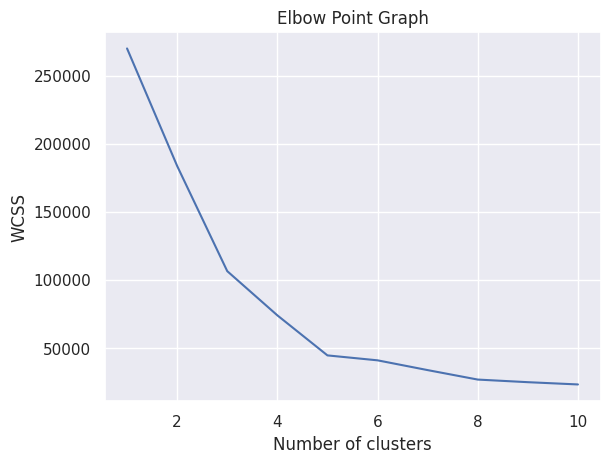

In [13]:
# plot elbow graph

sns.set()

plt.plot(range(1,11), wcss)
plt.title("Elbow Point Graph")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

This code visualizes the calculated WCSS values using a line plot, creating the **Elbow Method graph**. The x-axis represents the number of clusters, and the y-axis represents the WCSS value. We look for the 'elbow point' – the number of clusters after which the decrease in WCSS slows down significantly, suggesting an optimal number of clusters.
- `sns.set()`: Configures matplotlib and seaborn for consistent plotting aesthetics.
- `plt.plot(range(1,11), wcss)`: Plots the `wcss` values against the corresponding number of clusters.
- `plt.title()`, `plt.xlabel()`, `plt.ylabel()`: Set the title and labels for clarity.
- `plt.show()`: Displays the generated plot.

Based on the Elbow Method graph, plot indicates that **5 is chosen as the optimum number of clusters**, as the rate of decrease in WCSS significantly diminishes after this point.

In [15]:
# Training the K-means

model = KMeans(n_clusters=5, init="k-means++", random_state=0)

# Return label for each data point based on the cluster
Y = model.fit_predict(X)
print(Y)

[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 0 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


This cell trains the K-Means model with the chosen optimal number of 5 clusters and assigns each data point to its respective cluster.
- `model = KMeans(n_clusters=5, init="k-means++", random_state=0)`: Initializes the K-Means model with 5 clusters using the `k-means++` initialization and a `random_state` for reproducibility.
- `Y = model.fit_predict(X)`:
    - `fit_predict(X)`: This method first fits the K-Means model to the data `X` (learning the cluster centers) and then predicts the cluster label for each data point in `X`.
    - `Y`: This variable stores an array where each element is a cluster label (0, 1, 2, 3, or 4) corresponding to each data point in `X`.
- `print(Y)`: Displays the array of assigned cluster labels.

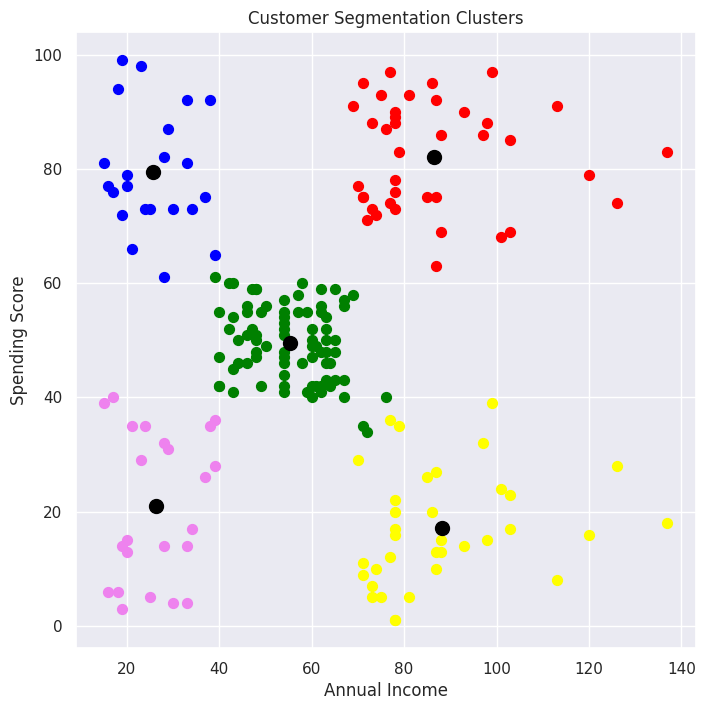

In [17]:
# Cluster Visualization
plt.figure(figsize=(8,8))
plt.scatter(X[Y==0,0], X[Y==0,1], s=50, c='green', label='Cluster 1')
plt.scatter(X[Y==1,0], X[Y==1,1], s=50, c='red', label='Cluster 2')
plt.scatter(X[Y==2,0], X[Y==2,1], s=50, c='yellow', label='Cluster 3')
plt.scatter(X[Y==3,0], X[Y==3,1], s=50, c='violet', label='Cluster 4')
plt.scatter(X[Y==4,0], X[Y==4,1], s=50, c='blue', label='Cluster 5')

plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], s=100, c='black', label='Centroids')

plt.title("Customer Segmentation Clusters")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

This code block visualizes the generated clusters, representing customer segments based on their Annual Income and Spending Score.
- `plt.figure(figsize=(8,8))`: Creates a figure for the plot with a specified size.
- `plt.scatter(X[Y==0,0], X[Y==0,1], s=50, c='green', label='Cluster 1')`: These lines plot the data points for each cluster:
    - `X[Y==0,0]`: Selects all data points from `X` that belong to Cluster 0 (`Y==0`) and retrieves their 'Annual Income' (first column, index 0).
    - `X[Y==0,1]`: Similarly, retrieves their 'Spending Score' (second column, index 1).
    - `s`, `c`, `label`: Control the size, color, and legend label for the plotted points.
- `plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], s=100, c='black', label='Centroids')`: Plots the center point of each cluster, which are the centroids identified by the K-Means algorithm.
- `plt.title()`, `plt.xlabel()`, `plt.ylabel()`: Set the title and axis labels for the visualization.
- `plt.show()`: Displays the final scatter plot, showing distinct customer segments and their centroids.